In [1]:
import numpy as np
from pyscf import gto, scf, lo, mp

basis = 'ccpvdz'
atoms = '''
C    -1.0478252   -1.4216736    0.0000000
C    -1.4545034   -0.8554459    1.2062048
C    -1.4545034   -0.8554459   -1.2062048
C    -2.2667970    0.2771610    1.2069539
C    -2.6714781    0.8450211    0.0000000
C    -2.2667970    0.2771610   -1.2069539
H    -1.1338534   -1.2920593   -2.1423150
H    -2.5824943    0.7163066   -2.1437977
H    -3.3030422    1.7232700    0.0000000
H    -2.5824943    0.7163066    2.1437977
H    -1.1338534   -1.2920593    2.1423150
H    -0.4060253   -2.2919049    0.0000000
C     1.0478252    1.4216736    0.0000000
C     1.4545034    0.8554459   -1.2062048
C     1.4545034    0.8554459    1.2062048
C     2.2667970   -0.2771610   -1.2069539
C     2.6714781   -0.8450211    0.0000000
C     2.2667970   -0.2771610    1.2069539
H     0.4060253    2.2919049    0.0000000
H     1.1338534    1.2920593    2.1423150
H     2.5824943   -0.7163066    2.1437977
H     3.3030422   -1.7232700    0.0000000
H     2.5824943   -0.7163066   -2.1437977
H     1.1338534    1.2920593   -2.1423150
'''

mol = gto.M(atom = atoms,
            basis = basis,
            verbose = 4,
            unit = 'A',
            symmetry = 0,
            charge = 0,
            spin = 0,
            max_memory = 200000,
            )

mf = scf.RHF(mol).density_fit()
mf.max_cycle = 100
mf.level_shift = 0.5
mf.kernel()

System: uname_result(system='Linux', node='sharmagroup-rn', release='7.0.0-29-generic', version='#29~24.04.2-Ubuntu SMP PREEMPT_DYNAMIC Wed Aug 12 17:25:56 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Sat Aug 22 14:19:22 2026
PySCF version 2.14.0
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD      c63a953ba603a5ad8c1d65d88da72aaf05ede4d8

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 24
[INPUT] num. electrons = 84
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = A
[INPUT] Symbol           X                Y                Z      unit          

np.float64(-461.43689919789824)

In [2]:
mymp = mp.MP2(mf).set_frozen()
mymp.kernel()
print(mymp.e_corr)


******** <class 'pyscf.mp.dfmp2.DFRMP2'> ********
nocc = 30, nmo = 216
frozen orbitals 12
max_memory 200000 MB (current use 526 MB)
E(DFRMP2) = -463.014971408798  E_corr = -1.57807221090007
E(SCS-DFRMP2) = -462.969210340048  E_corr = -1.53231114214943
E_corr(same-spin) = -0.41697174338153
E_corr(oppo-spin) = -1.16110046751854
-1.5780722109000709


In [3]:
options = {
           'eql_time': 40,
           'n_blocks': 50,
           'n_walkers': 100,
           'mix_precision': True,
           'max_memory': 300000,
           'seed': 17,
           'walker_type': 'rhf',
           'trial': 'rpt2ccsd',
           }

from afqmc.lno_afqmc import tools, lno_afqmc_test
lo_coeff, frag_list, frag_name = tools.iao_fragment(
        mf,
        frag_type='h2heavy',
        more_loc='pm',
        save2=None,
        read_from=None,
        )

threshs = [1e-4, 3e-5, 1e-5, 3e-6, 1e-6]



******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
algorithm = ciah
pop_method = meta_lowdin
exponent = 2
Set conv_tol_grad to 0.000316228
Init f(x)= 71.511957276831  |g|= 0.0215449
macro= 1  f(x)= 71.512562997833  delta_f= 0.000605721  |g|= 0.000764913  3 KF 9 Hx
macro= 2  f(x)= 71.512884776001  delta_f= 0.000321778  |g|= 0.000211563  6 KF 36 Hx
macro= 3  f(x)= 71.51288860687  delta_f= 3.83087e-06  |g|= 0.000177582  1 KF 5 Hx
macro= 4  f(x)= 71.512888722254  delta_f= 1.15384e-07  |g|= 4.80403e-05  1 KF 1 Hx
macro X = 4  f(x)= 71.512888722254  |g|= 4.80403e-05  8 intor 11 KF 51 Hx


In [4]:
emp1 = np.zeros(len(threshs))
size1 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    lno_thresh = [lno_thresh, lno_thresh]
    emp1[i], _, _, _, size1[i] \
        = lno_afqmc_test.run_afqmc(
                mf,
                lo_coeff,
                frag_list,
                frag_name,
                lno_thresh = lno_thresh,
                qmc_options = options,
                chol_cut = 1e-5,
                target_qmc_err = 5e-4,
                run_frag = None,
                nfrozen = None,
                run_mp = True,
                run_cc = False,
                run_qmc = False,
                plot_las = False,
                )



 ******* LNO-CALCULATION ******* 

LNO THRESHOLD = [0.0001, 0.0001]
LNO freezes at least the chemcore orbitals for each element!
LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
Run Fragment range(0, 12)

CPU/GPU pipeline: ON (prefetch depth 1)
  the LNO-MP2/CCSD of the next fragment(s) run on the CPU while the current fragment's AFQMC occupies the GPU


======================== LNO-FRAGMENT [C0H11] 1/(12,12) ========================
Fragment Num.  1
Fragment Idx.  1
Fragment Name  C0H11
LNO THRESHOLD  [0.0001, 0.0001]
PySCF Threads  16
LNO-LAS: 21/42 Occ | 53/186 Vir | 74/228 MOs
LNO-MP2 Fragment Energy:  -0.12859970
LNO-CCSD Fragment Energy: 0.00000000
LNO-CPU time (s):         0.37 (LAS 0.24 | MP2 0.14 | CCSD 0.00)
LNO-CPU wait time (s):    0.37 (0.6% hidden)


======================== LNO-FRAGMENT [C1H10] 2/(12,12) ========================
Fragment Num.  2
Fragment Idx.  2
Fragment Name  C1H10
LNO THRESHOLD  [0.0001, 0.0001]
PySCF Thread

In [5]:
emp2 = np.zeros(len(threshs))
size2 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):

    emp2[i], _, _, _, size2[i] \
        = lno_afqmc_test.run_afqmc(
                mf,
                lo_coeff,
                frag_list,
                frag_name,
                lno_thresh = lno_thresh,
                qmc_options = options,
                chol_cut = 1e-5,
                target_qmc_err = 5e-4,
                run_frag = None,
                nfrozen = None,
                run_mp = True,
                run_cc = False,
                run_qmc = False,
                plot_las = False,
                )


 ******* LNO-CALCULATION ******* 

LNO THRESHOLD = 0.0001
LNO freezes at least the chemcore orbitals for each element!
LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
Run Fragment range(0, 12)

CPU/GPU pipeline: ON (prefetch depth 1)
  the LNO-MP2/CCSD of the next fragment(s) run on the CPU while the current fragment's AFQMC occupies the GPU


======================== LNO-FRAGMENT [C0H11] 1/(12,12) ========================
Fragment Num.  1
Fragment Idx.  1
Fragment Name  C0H11
LNO THRESHOLD  [0.001, 0.0001]
PySCF Threads  16
LNO-LAS: 12/42 Occ | 53/186 Vir | 65/228 MOs
LNO-MP2 Fragment Energy:  -0.12693532
LNO-CCSD Fragment Energy: 0.00000000
LNO-CPU time (s):         0.34 (LAS 0.25 | MP2 0.09 | CCSD 0.00)
LNO-CPU wait time (s):    0.34 (0.7% hidden)


======================== LNO-FRAGMENT [C1H10] 2/(12,12) ========================
Fragment Num.  2
Fragment Idx.  2
Fragment Name  C1H10
LNO THRESHOLD  [0.001, 0.0001]
PySCF Threads  16
LNO-LA

[ 74. 102. 126. 149. 164.]
[-1.54263394 -1.56570112 -1.57419135 -1.57717161 -1.57776242]
[ 65.  93. 119. 146. 162.]
[-1.52710893 -1.56301531 -1.57240284 -1.57679334 -1.57762842]


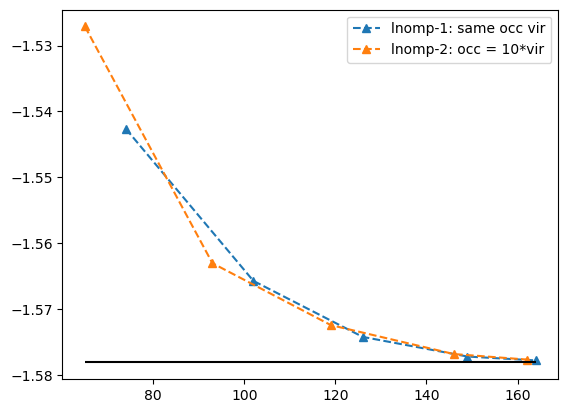

In [6]:
print(size1)
print(emp1)
print(size2)
print(emp2)
from matplotlib import pyplot as plt
plt.plot(size1, emp1, "^--", color="C0", label="lnomp-1: same occ vir")
plt.plot(size2, emp2, "^--", color="C1", label="lnomp-2: occ = 10*vir")
plt.hlines(mymp.e_corr, xmin=min(np.hstack((size1,size2))), xmax=max(np.hstack((size1,size2))), colors='k')
plt.legend()
plt.show()